# Cancer detection → TIL infiltration pipeline
1. `Cancer_detection.keras` classifies the image (9 classes).
2. Only if a **malignant** class is predicted, `til_infiltration_classifier_CNN.keras` checks for TIL infiltration.

Run the cells top to bottom. Upload both `.keras` files to `/content/` (drag into the Files panel) or to Google Drive first.

In [2]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
CANCER_MODEL_PATH = "/content/Cancer_detection.keras"
TIL_MODEL_PATH    = "/content/til_infiltration_classifier_CNN.keras"

IMG_SIZE = (224, 224)   # same as the training notebook

# class_names = sorted(sub-folder names) in the training notebook
CANCER_CLASS_NAMES = [
    "breast_benign",     # 0
    "breast_malignant",  # 1
    "colon_aca",         # 2
    "colon_bnt",         # 3
    "kidney_normal",     # 4
    "kidney_tumor",      # 5
    "lung_aca",          # 6
    "lung_bnt",          # 7
    "lung_scc",          # 8
]
CANCER_CLASSES = {"breast_malignant", "colon_aca", "kidney_tumor", "lung_aca", "lung_scc"}

# TIL model: sigmoid output. Assumes output near 1 = TIL positive.
TIL_POSITIVE_IS_ONE = True
TIL_THRESHOLD = 0.5

In [3]:
cancer_model = tf.keras.models.load_model(CANCER_MODEL_PATH)
til_model    = tf.keras.models.load_model(TIL_MODEL_PATH)
print("Models loaded.")

Models loaded.


In [6]:
def load_image(path):
    """Same preprocessing as the training notebook: decode -> 3 channels ->
    resize 224x224 -> float32 in 0-255 (models have Rescaling(1/255) built in)."""
    try:
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        return tf.expand_dims(img, 0).numpy()
    except Exception:
        # fallback for formats TF can't decode (e.g. TIFF)
        pil = Image.open(path).convert("RGB")
        arr = tf.image.resize(np.asarray(pil, dtype=np.float32), IMG_SIZE)
        return tf.expand_dims(arr, 0).numpy()


def analyse(path, show=True):
    x = load_image(path)

    # ---- Stage 1: cancer detection ----
    probs = cancer_model.predict(x, verbose=0)[0]
    idx = int(np.argmax(probs))
    label, conf = CANCER_CLASS_NAMES[idx], float(probs[idx])
    is_cancer = label in CANCER_CLASSES

    result = {"image": path, "predicted_class": label, "confidence": conf,
              "cancer_detected": is_cancer, "til_infiltration": None, "til_probability": None}

    # ---- Stage 2: only if cancer detected ----
    if is_cancer:
        p1 = float(til_model.predict(x, verbose=0)[0][0])
        p_til = p1 if TIL_POSITIVE_IS_ONE else 1.0 - p1
        result["til_infiltration"] = p_til >= TIL_THRESHOLD
        result["til_probability"] = p_til

    if show:
        plt.figure(figsize=(4, 4))
        plt.imshow(x[0].astype("uint8")); plt.axis("off")
        plt.title(os.path.basename(path)); plt.show()
        print(f"Stage 1 class : {label} ({conf:.1%})")
        if not is_cancer:
            print("Cancer        : NOT detected -> TIL model skipped")
        else:
            print("Cancer        : DETECTED")
            verdict = "PRESENT" if result["til_infiltration"] else "ABSENT"
            print(f"TIL infiltration  : {verdict} (P(TIL) = {result['til_probability']:.1%})")
    return result

## Run on an image
Option A: upload from your computer.

Saving Screenshot 2026-09-29 094737.png to Screenshot 2026-09-29 094737.png


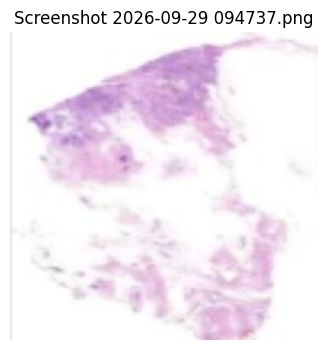

Stage 1 class : breast_malignant (94.1%)
Cancer        : DETECTED
TIL infiltration  : ABSENT (P(TIL) = 1.6%)


In [11]:
from google.colab import files
uploaded = files.upload()          # pick one or more images
results = [analyse(name) for name in uploaded.keys()]

Option B: use a path already in Colab / Drive.

In [ ]:
# results = [analyse("/content/my_image.jpg")]